In [4]:
!pip -q install scikit-learn pandas

In [5]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

In [6]:
# Load the training dataset
newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

print(f"Total Documents: {len(newsgroups.data)}")
print(f"Total Categories: {len(newsgroups.target_names)}")

Total Documents: 11314
Total Categories: 20


In [7]:
df = pd.DataFrame({
    "text": newsgroups.data,
    "category": [newsgroups.target_names[i] for i in newsgroups.target]
})

df.head()

,text,category
0,I was wondering if anyone out there could enli...,rec.autos
1,A fair number of brave souls who upgraded thei...,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",sci.space


In [8]:
print(df.shape)
print()

print(df.info())

(11314, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11314 entries, 0 to 11313
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      11314 non-null  object
 1   category  11314 non-null  object
dtypes: object(2)
memory usage: 176.9+ KB
None


In [9]:
df['category'].value_counts()

,count
category,
rec.sport.hockey,600
soc.religion.christian,599
rec.motorcycles,598
rec.sport.baseball,597
sci.crypt,595
sci.med,594
rec.autos,594
sci.space,593
comp.windows.x,593


In [10]:
print("Category:")
print(df.loc[0, "category"])

print("\nDocument:\n")
print(df.loc[0, "text"])

Category:
rec.autos

Document:

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


In [12]:
import os

print(os.listdir())

['.config', 'sample_data']


In [13]:
print(df.head())

                                                text               category
0  I was wondering if anyone out there could enli...              rec.autos
1  A fair number of brave souls who upgraded thei...  comp.sys.mac.hardware
2  well folks, my mac plus finally gave up the gh...  comp.sys.mac.hardware
3  \nDo you have Weitek's address/phone number?  ...          comp.graphics
4  From article <C5owCB.n3p@world.std.com>, by to...              sci.space


In [14]:
!pip -q install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [15]:
import re
import pandas as pd

In [16]:
def clean_text(text):

    if pd.isna(text):
        return ""

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [17]:
df["clean_text"] = df["text"].apply(clean_text)

In [18]:
print("Original:\n")
print(df.loc[0, "text"])

print("\n" + "="*80 + "\n")

print("Cleaned:\n")
print(df.loc[0, "clean_text"])

Original:

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


Cleaned:

i was wondering if anyone out there could enlighten me on this car i saw the other day it was a door sports car looked to be from the late s early s it was called a bricklin the doors were really small in addition the front bumper was separate from the rest of the body this is all i know if anyone can tellme a model name engine specs years of production where this car is made history or whatever info you have on this funky looking car please e mail


In [19]:
df = df[df["clean_text"].str.len() > 20]

print("Remaining documents:", len(df))

Remaining documents: 10913


In [20]:
df[["clean_text", "category"]].head()

,clean_text,category
0,i was wondering if anyone out there could enli...,rec.autos
1,a fair number of brave souls who upgraded thei...,comp.sys.mac.hardware
2,well folks my mac plus finally gave up the gho...,comp.sys.mac.hardware
3,do you have weitek s address phone number i d ...,comp.graphics
4,from article by tom a baker my understanding i...,sci.space


In [21]:
import spacy

# Load English model
nlp = spacy.load("en_core_web_sm")

In [22]:
def extract_entities(text):

    doc = nlp(text)

    entities = []

    for ent in doc.ents:
        entities.append({
            "Entity": ent.text,
            "Label": ent.label_
        })

    return entities

In [23]:
sample_entities = extract_entities(df.loc[0, "clean_text"])

sample_entities

[{'Entity': 'the late s early s', 'Label': 'DATE'},
 {'Entity': 'bricklin', 'Label': 'GPE'}]

In [24]:
entity_data = []

for text in df["clean_text"].head(100):

    entities = extract_entities(text)

    entity_data.append(entities)

print("Processed", len(entity_data), "documents")

Processed 100 documents


In [25]:
for i in range(5):

    print("="*60)

    print("Document", i)

    print(entity_data[i])

Document 0
[{'Entity': 'the late s early s', 'Label': 'DATE'}, {'Entity': 'bricklin', 'Label': 'GPE'}]
Document 1
[{'Entity': 'the next two days', 'Label': 'DATE'}]
Document 2
[{'Entity': 'this weekend', 'Label': 'DATE'}, {'Entity': 'this summer', 'Label': 'DATE'}, {'Entity': 'the and day to day', 'Label': 'DATE'}, {'Entity': 'tom willis', 'Label': 'PERSON'}]
Document 3
[{'Entity': 'weitek s address', 'Label': 'PERSON'}]
Document 4
[]


In [26]:
rows = []

for doc_id, entities in enumerate(entity_data):

    for entity in entities:

        rows.append({
            "Document": doc_id,
            "Entity": entity["Entity"],
            "Type": entity["Label"]
        })

entity_df = pd.DataFrame(rows)

entity_df.head()

,Document,Entity,Type
0,0,the late s early s,DATE
1,0,bricklin,GPE
2,1,the next two days,DATE
3,2,this weekend,DATE
4,2,this summer,DATE


In [27]:
entity_df["Type"].value_counts()

,count
Type,
NORP,158
DATE,120
ORG,117
PERSON,110
GPE,84
CARDINAL,78
ORDINAL,24
LOC,7
QUANTITY,6


In [28]:
entity_df.to_csv("entities.csv", index=False)

print("Entities saved successfully!")

Entities saved successfully!


In [30]:
def extract_triples(text):

    doc = nlp(text)

    triples = []

    for token in doc:

        # Main verb
        if token.pos_ == "VERB":

            subject = None
            obj = None

            # Find subject and object
            for child in token.children:

                if child.dep_ in ("nsubj", "nsubjpass"):
                    subject = child

                elif child.dep_ in ("dobj",
                                    "attr",
                                    "oprd",
                                    "pobj"):
                    obj = child

            if subject and obj:

                triples.append(
                    (
                        subject.text,
                        token.lemma_,
                        obj.text
                    )
                )

    return triples

In [31]:
sample = df.loc[0, "clean_text"]

print(sample)

i was wondering if anyone out there could enlighten me on this car i saw the other day it was a door sports car looked to be from the late s early s it was called a bricklin the doors were really small in addition the front bumper was separate from the rest of the body this is all i know if anyone can tellme a model name engine specs years of production where this car is made history or whatever info you have on this funky looking car please e mail


In [32]:
for i in range(10):

    triples = extract_triples(df.loc[i, "clean_text"])

    if len(triples) > 0:

        print("="*70)

        print("Document:", i)

        print(df.loc[i, "clean_text"][:250])

        print()

        print("Triples")

        print(triples)

Document: 0
i was wondering if anyone out there could enlighten me on this car i saw the other day it was a door sports car looked to be from the late s early s it was called a bricklin the doors were really small in addition the front bumper was separate from t

Triples
[('anyone', 'enlighten', 'me'), ('it', 'call', 'bricklin'), ('anyone', 'tellme', 'mail'), ('car', 'make', 'history'), ('you', 'have', 'info')]
Document: 1
a fair number of brave souls who upgraded their si clock oscillator have shared their experiences for this poll please send a brief message detailing your experiences with the procedure top speed attained cpu rated speed add on cards and adapters hea

Triples
[('who', 'upgrade', 'oscillator'), ('number', 'share', 'experiences'), ('cpu', 'rat', 'speed'), ('you', 'do', 'upgrade'), ('t', 'answer', 'poll')]
Document: 2
well folks my mac plus finally gave up the ghost this weekend after starting life as a k way back in sooo i m in the market for a new machine a bit sooner

In [33]:
for i in range(10):

    triples = extract_triples(df.loc[i, "clean_text"])

    if len(triples) > 0:

        print("="*70)

        print("Document:", i)

        print(df.loc[i, "clean_text"][:250])

        print()

        print("Triples")

        print(triples)

Document: 0
i was wondering if anyone out there could enlighten me on this car i saw the other day it was a door sports car looked to be from the late s early s it was called a bricklin the doors were really small in addition the front bumper was separate from t

Triples
[('anyone', 'enlighten', 'me'), ('it', 'call', 'bricklin'), ('anyone', 'tellme', 'mail'), ('car', 'make', 'history'), ('you', 'have', 'info')]
Document: 1
a fair number of brave souls who upgraded their si clock oscillator have shared their experiences for this poll please send a brief message detailing your experiences with the procedure top speed attained cpu rated speed add on cards and adapters hea

Triples
[('who', 'upgrade', 'oscillator'), ('number', 'share', 'experiences'), ('cpu', 'rat', 'speed'), ('you', 'do', 'upgrade'), ('t', 'answer', 'poll')]
Document: 2
well folks my mac plus finally gave up the ghost this weekend after starting life as a k way back in sooo i m in the market for a new machine a bit sooner

In [34]:
triples = []

for text in df["clean_text"].head(200):

    triples.extend(extract_triples(text))

print("Total Triples:", len(triples))

Total Triples: 1071


In [35]:
triple_df = pd.DataFrame(
    triples,
    columns=[
        "Subject",
        "Relation",
        "Object"
    ]
)

triple_df.head()

,Subject,Relation,Object
0,anyone,enlighten,me
1,it,call,bricklin
2,anyone,tellme,mail
3,car,make,history
4,you,have,info


In [36]:
triple_df = triple_df.drop_duplicates()

print("Unique Triples:", len(triple_df))

Unique Triples: 1053


In [37]:
triple_df["Relation"].value_counts().head(20)

,count
Relation,
have,115
use,43
get,30
s,27
do,26
m,25
see,22
take,22
make,18


In [38]:
triple_df["Relation"].value_counts().head(20)

,count
Relation,
have,115
use,43
get,30
s,27
do,26
m,25
see,22
take,22
make,18


In [39]:
triple_df.to_csv(
    "triples.csv",
    index=False
)

print("Triples saved successfully!")

Triples saved successfully!


In [41]:
!pip -q install networkx matplotlib

In [42]:
import networkx as nx
import matplotlib.pyplot as plt

In [43]:
G = nx.MultiDiGraph()

In [44]:
for _, row in triple_df.iterrows():

    subject = row["Subject"]
    relation = row["Relation"]
    obj = row["Object"]

    G.add_node(subject)
    G.add_node(obj)

    G.add_edge(
        subject,
        obj,
        relation=relation
    )

In [45]:
print("Knowledge Graph Statistics")
print("-"*35)

print("Number of Nodes :", G.number_of_nodes())
print("Number of Edges :", G.number_of_edges())

Knowledge Graph Statistics
-----------------------------------
Number of Nodes : 943
Number of Edges : 1053


In [46]:
list(G.nodes())[:20]

['anyone',
 'me',
 'it',
 'bricklin',
 'mail',
 'car',
 'history',
 'you',
 'info',
 'who',
 'oscillator',
 'number',
 'experiences',
 'cpu',
 'speed',
 'upgrade',
 't',
 'poll',
 'folks',
 'ghost']

In [47]:
for edge in list(G.edges(data=True))[:20]:
    print(edge)

('anyone', 'me', {'relation': 'enlighten'})
('anyone', 'me', {'relation': 'tell'})
('anyone', 'me', {'relation': 'point'})
('anyone', 'mail', {'relation': 'tellme'})
('anyone', 'sites', {'relation': 'know'})
('anyone', 'difference', {'relation': 'tell'})
('anyone', 'info', {'relation': 'have'})
('anyone', 'idea', {'relation': 'have'})
('anyone', 'ron', {'relation': 'tell'})
('anyone', 'manual', {'relation': 'have'})
('me', 'money', {'relation': 'spend'})
('me', 'alot', {'relation': 'thatnk'})
('me', 'it', {'relation': 'put'})
('me', 'thanks', {'relation': 'heave'})
('it', 'bricklin', {'relation': 'call'})
('it', 'chip', {'relation': 'use'})
('it', 'technology', {'relation': 'work'})
('it', 'fault', {'relation': 's'})
('it', 'unlikely', {'relation': 'seem'})
('it', 'step', {'relation': 's'})


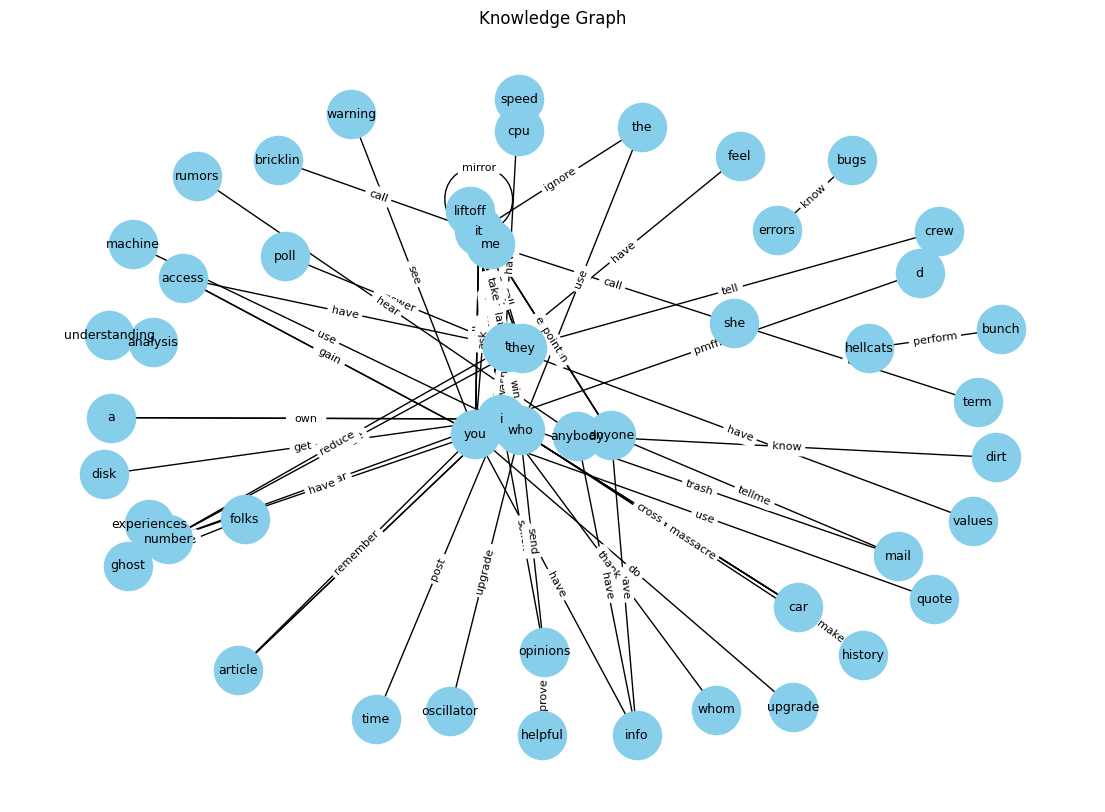

In [48]:
sub_nodes = list(G.nodes())[:50]

H = G.subgraph(sub_nodes)

plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    H,
    seed=42
)

nx.draw_networkx_nodes(
    H,
    pos,
    node_size=1200,
    node_color="skyblue"
)

nx.draw_networkx_labels(
    H,
    pos,
    font_size=9
)

nx.draw_networkx_edges(
    H,
    pos,
    arrows=True
)

edge_labels = nx.get_edge_attributes(H,"relation")

nx.draw_networkx_edge_labels(
    H,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Knowledge Graph")

plt.axis("off")

plt.show()

In [49]:
nx.write_graphml(
    G,
    "knowledge_graph.graphml"
)

print("Graph saved!")

Graph saved!


In [50]:
nx.write_gexf(
    G,
    "knowledge_graph.gexf"
)

print("GEXF saved!")

GEXF saved!


In [51]:
files.download("knowledge_graph.gexf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 943
Edges: 1053


In [53]:
# Number of nodes to display
MAX_NODES = 30

# Select first 30 nodes
selected_nodes = list(G.nodes())[:MAX_NODES]

# Create subgraph
H = G.subgraph(selected_nodes).copy()

print(f"Displaying {H.number_of_nodes()} nodes")
print(f"Displaying {H.number_of_edges()} edges")

Displaying 30 nodes
Displaying 74 edges


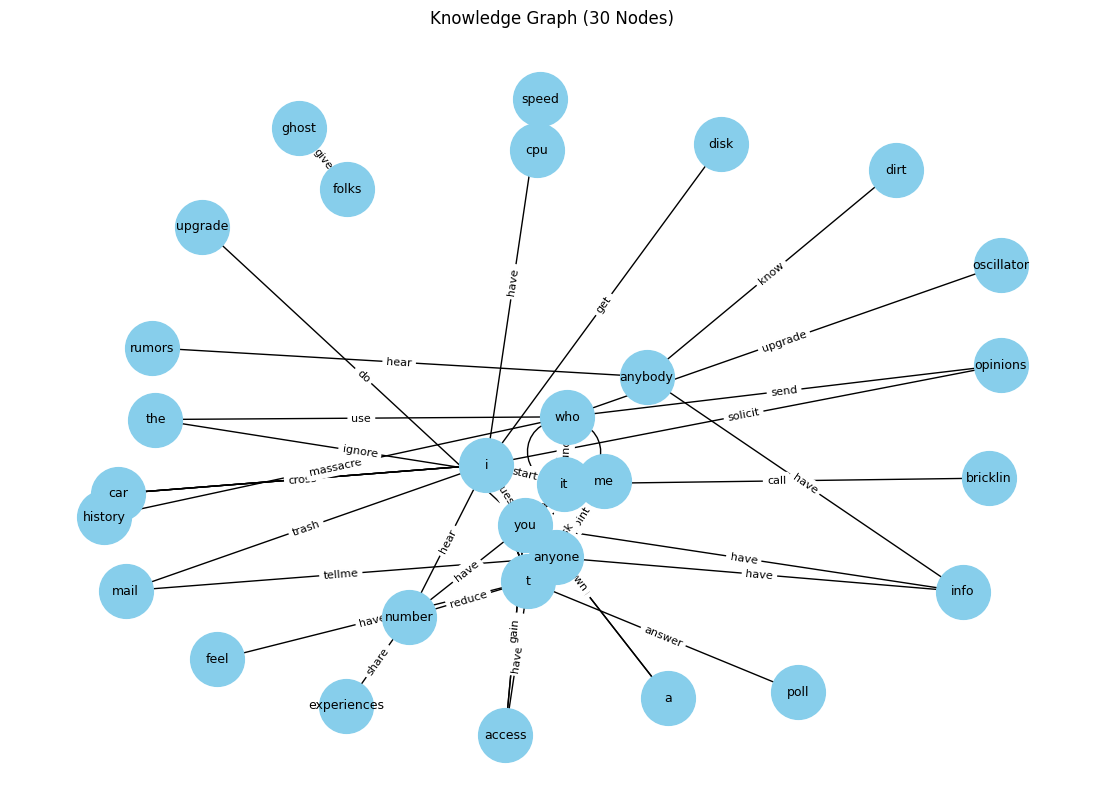

In [54]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(H, seed=42)

nx.draw_networkx_nodes(
    H,
    pos,
    node_size=1500,
    node_color="skyblue"
)

nx.draw_networkx_labels(
    H,
    pos,
    font_size=9
)

nx.draw_networkx_edges(
    H,
    pos,
    arrows=True,
    arrowstyle="->",
    arrowsize=15
)

edge_labels = nx.get_edge_attributes(H, "relation")

nx.draw_networkx_edge_labels(
    H,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Knowledge Graph (30 Nodes)")
plt.axis("off")
plt.show()

In [55]:
# Number of important nodes
MAX_NODES = 30

# Sort by degree
top_nodes = sorted(
    G.degree,
    key=lambda x: x[1],
    reverse=True
)[:MAX_NODES]

selected_nodes = [node for node, degree in top_nodes]

H = G.subgraph(selected_nodes).copy()

print("Nodes:", H.number_of_nodes())
print("Edges:", H.number_of_edges())

Nodes: 30
Edges: 147


In [56]:
MIN_DEGREE = 2

selected_nodes = [
    node
    for node, degree in G.degree()
    if degree >= MIN_DEGREE
]

H = G.subgraph(selected_nodes).copy()

print("Nodes:", H.number_of_nodes())
print("Edges:", H.number_of_edges())

Nodes: 217
Edges: 452


Displaying 15 nodes
Displaying 100 edges


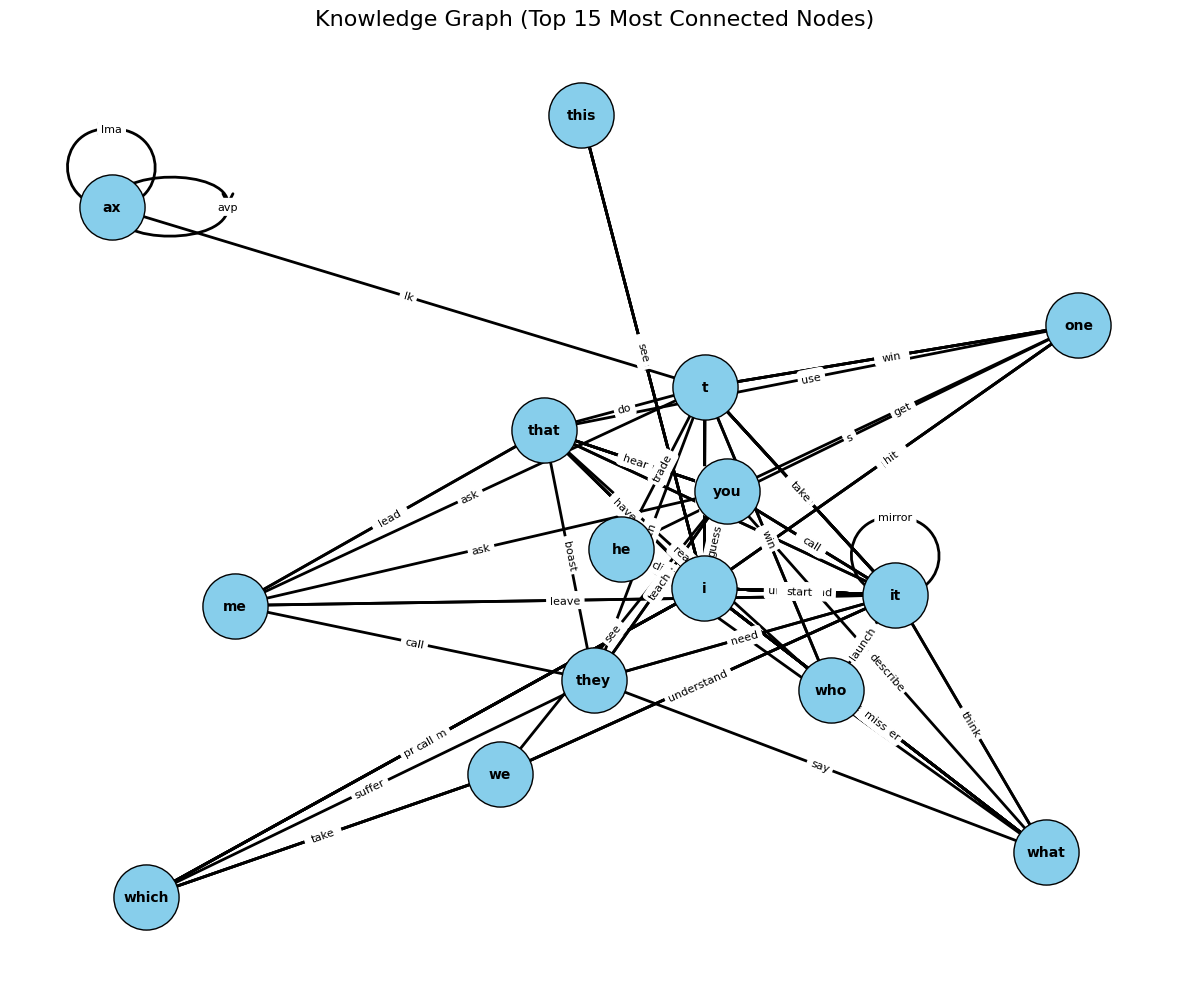

In [57]:
import networkx as nx
import matplotlib.pyplot as plt

# ==============================
# Select Top 15 Most Connected Nodes
# ==============================

MAX_NODES = 15

# Sort nodes by degree (highest first)
top_nodes = sorted(
    G.degree(),
    key=lambda x: x[1],
    reverse=True
)[:MAX_NODES]

# Extract node names
selected_nodes = [node for node, degree in top_nodes]

# Create subgraph
H = G.subgraph(selected_nodes).copy()

print(f"Displaying {H.number_of_nodes()} nodes")
print(f"Displaying {H.number_of_edges()} edges")

# ==============================
# Visualization
# ==============================

plt.figure(figsize=(12, 10))

# Better layout
pos = nx.spring_layout(
    H,
    k=1.2,
    seed=42
)

# Draw nodes
nx.draw_networkx_nodes(
    H,
    pos,
    node_color="skyblue",
    node_size=2200,
    edgecolors="black"
)

# Draw labels
nx.draw_networkx_labels(
    H,
    pos,
    font_size=10,
    font_weight="bold"
)

# Draw edges
nx.draw_networkx_edges(
    H,
    pos,
    arrows=True,
    arrowstyle="->",
    arrowsize=18,
    width=2
)

# Draw relation labels
edge_labels = nx.get_edge_attributes(H, "relation")

nx.draw_networkx_edge_labels(
    H,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Knowledge Graph (Top 15 Most Connected Nodes)", fontsize=16)
plt.axis("off")
plt.tight_layout()

plt.show()